# Airbnb Price Prediction Analysis

This notebook follows the project outline and milestone report for the Airbnb price prediction regression project. It covers:

- data loading and cleaning
- exploratory data analysis
- baseline models
- regression modeling
- cross-validation
- final evaluation and interpretation

**Dataset expected:** U.S. Airbnb Open Data from Kaggle.

Update the `DATA_PATH` below to point to your CSV file before running. This notebook was structured from the team outline and milestone report.

In [5]:
# Auto-install dependencies
import subprocess
import sys

try:
    import numpy, pandas, matplotlib, seaborn, sklearn
except ImportError:
    print("Installing required packages...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", 
                          "numpy>=1.20.0", "pandas>=1.3.0", "matplotlib>=3.4.0", 
                          "seaborn>=0.11.0", "scikit-learn>=1.0.0"])
    print("✓ Dependencies installed successfully!")

In [6]:
# Core imports
import warnings
warnings.filterwarnings("ignore")

import re
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import (
    train_test_split, cross_validate, KFold, RandomizedSearchCV
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler

## 1. Configuration

The report frames this as a **regression** problem with **price** as the continuous target, using listing, review, host, and geographic features. It also notes a right-skewed price distribution, missing review-related fields, and the need to clean price strings. fileciteturn0file2L21-L97

In [7]:
# Change this to your local CSV path
DATA_PATH = "AB_US_2023.csv"

# Toggle these depending on your experiment
USE_LOG_TARGET = True
REMOVE_EXTREME_OUTLIERS = True
OUTLIER_UPPER_QUANTILE = 0.99

RANDOM_STATE = 42
TEST_SIZE = 0.20
CV_FOLDS = 5

## 2. Load data

In [9]:
if not Path(DATA_PATH).exists():
    raise FileNotFoundError(
        f"Could not find dataset at {DATA_PATH}. "
        "Download the Kaggle CSV and update DATA_PATH before running."
    )

df = pd.read_csv(DATA_PATH)
print(f"Shape: {df.shape}")
df.head()

Shape: (232147, 18)


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,city
0,958,"Bright, Modern Garden Unit - 1BR/1BTH",1169,Holly,NaN,Western Addition,37.77028,-122.43317,Entire home/apt,202,2,383,2023-02-19,2.31,1,128,59,San Francisco
1,5858,Creative Sanctuary,8904,Philip And Tania,NaN,Bernal Heights,37.74474,-122.42089,Entire home/apt,235,30,111,2017-08-06,0.66,1,365,0,San Francisco
2,8142,Friendly Room Apt. Style -UCSF/USF - San Franc...,21994,Aaron,NaN,Haight Ashbury,37.76555,-122.45213,Private room,56,32,9,2022-10-27,0.09,13,365,1,San Francisco
3,8339,Historic Alamo Square Victorian,24215,Rosy,NaN,Western Addition,37.77564,-122.43642,Entire home/apt,575,9,28,2019-06-28,0.17,2,365,0,San Francisco
4,8739,"Mission Sunshine, with Private Bath",7149,Ivan & Wendy,NaN,Mission,37.76030,-122.42197,Private room,110,1,770,2023-02-25,4.65,2,159,34,San Francisco


## 3. Inspect columns and basic info

In [10]:
print(df.columns.tolist())
print()
df.info()

['id', 'name', 'host_id', 'host_name', 'neighbourhood_group', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'last_review', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365', 'number_of_reviews_ltm', 'city']

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 232147 entries, 0 to 232146
Data columns (total 18 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   id                              232147 non-null  int64  
 1   name                            232131 non-null  object 
 2   host_id                         232147 non-null  int64  
 3   host_name                       232134 non-null  object 
 4   neighbourhood_group             96500 non-null   object 
 5   neighbourhood                   232147 non-null  object 
 6   latitude                        232147 non-null  float64
 7   longitude                       23214

In [11]:
df.describe(include="all").T.head(20)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,232147.0,NaN,NaN,NaN,258458021912406368.0,346598536640871936.0,6.0,26388957.5,48963066.0,663301392245389184.0,858101367585572736.0
name,232131,220164,Presidential Suite In A Mansion,150,NaN,NaN,NaN,NaN,NaN,NaN,NaN
host_id,232147.0,NaN,NaN,NaN,158224798.874907,158716378.001844,23.0,22992416.0,100578284.0,268693041.5,506938352.0
host_name,232134,29368,Blueground,4305,NaN,NaN,NaN,NaN,NaN,NaN,NaN
neighbourhood_group,96500,30,City of Los Angeles,22204,NaN,NaN,NaN,NaN,NaN,NaN,NaN
neighbourhood,232147,1412,Unincorporated Areas,11882,NaN,NaN,NaN,NaN,NaN,NaN,NaN
latitude,232147.0,NaN,NaN,NaN,36.610585,5.126523,25.957323,33.976225,36.190556,40.71744,47.73401
longitude,232147.0,NaN,NaN,NaN,-98.301436,19.706929,-123.08913,-118.315111,-97.72767,-77.026222,-70.996
room_type,232147,4,Entire home/apt,169142,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,232147.0,NaN,NaN,NaN,259.468001,1024.645918,0.0,91.0,149.0,250.0,100000.0


## 4. Utility helpers

The dataset version can vary a bit across uploads, so these helpers try to locate expected columns by common aliases.

In [12]:
def first_existing_column(columns, candidates):
    lower_map = {c.lower(): c for c in columns}
    for cand in candidates:
        if cand.lower() in lower_map:
            return lower_map[cand.lower()]
    return None

def clean_price_series(series: pd.Series) -> pd.Series:
    # Handles strings like "$123.00", "$1,250", "125"
    return (
        series.astype(str)
        .str.replace(r"[\$,]", "", regex=True)
        .str.strip()
        .replace({"": np.nan, "nan": np.nan, "None": np.nan})
        .astype(float)
    )

def add_missing_review_indicators(df: pd.DataFrame, rpm_col: str | None, last_review_col: str | None) -> pd.DataFrame:
    out = df.copy()
    if rpm_col and rpm_col in out.columns:
        out["has_reviews_per_month"] = out[rpm_col].notna().astype(int)
    if last_review_col and last_review_col in out.columns:
        out["has_last_review"] = out[last_review_col].notna().astype(int)
    return out

## 5. Identify target and candidate features

In [ ]:
price_col = first_existing_column(df.columns, ["price"])
city_col = first_existing_column(df.columns, ["city"])
lat_col = first_existing_column(df.columns, ["latitude", "lat"])
lon_col = first_existing_column(df.columns, ["longitude", "long", "lng"])
room_type_col = first_existing_column(df.columns, ["room_type"])
minimum_nights_col = first_existing_column(df.columns, ["minimum_nights"])
availability_col = first_existing_column(df.columns, ["availability_365"])
reviews_col = first_existing_column(df.columns, ["number_of_reviews"])
reviews_pm_col = first_existing_column(df.columns, ["reviews_per_month"])
reviews_ltm_col = first_existing_column(df.columns, ["number_of_reviews_ltm"])
host_listings_col = first_existing_column(df.columns, ["calculated_host_listings_count"])
neighborhood_col = first_existing_column(df.columns, ["neighbourhood", "neighborhood"])
neighborhood_group_col = first_existing_column(df.columns, ["neighbourhood_group", "neighborhood_group"])
last_review_col = first_existing_column(df.columns, ["last_review"])

assert price_col is not None, "Could not find a price column."

# NOTE: neighbourhood is NOT included as a direct feature to avoid
# a massive one-hot-encoded matrix. Instead we frequency-encode it in the
# feature engineering step (neighbourhood_freq).
candidate_features = [
    city_col,
    neighborhood_group_col,
    room_type_col,
    lat_col,
    lon_col,
    minimum_nights_col,
    availability_col,
    reviews_col,
    reviews_pm_col,
    reviews_ltm_col,
    host_listings_col,
]
candidate_features = [c for c in candidate_features if c is not None]

print("Target:", price_col)
print("Candidate features:", candidate_features)
print(f"(neighbourhood will be frequency-encoded separately — {df[neighborhood_col].nunique()} unique values)")

Target: price
Candidate features: ['city', 'neighbourhood_group', 'room_type', 'latitude', 'longitude', 'minimum_nights', 'availability_365', 'number_of_reviews', 'reviews_per_month', 'number_of_reviews_ltm', 'calculated_host_listings_count']
(neighbourhood will be frequency-encoded separately — 1412 unique values)


## 6. Clean target and basic preprocessing

This follows the report's plan:
- convert price from string to numeric
- account for missing review fields
- optionally remove extreme outliers
- optionally model `log(price)` because price is strongly right-skewed fileciteturn0file2L70-L97

In [ ]:
df = df.copy()

# Clean target
df[price_col] = clean_price_series(df[price_col])

# Add simple missingness indicators for review fields
df = add_missing_review_indicators(df, reviews_pm_col, last_review_col)

# --- Feature engineering ---
# Log-transform right-skewed numeric features to reduce outlier influence
for col in [minimum_nights_col, reviews_col, reviews_ltm_col, host_listings_col]:
    if col and col in df.columns:
        df[f"log1p_{col}"] = np.log1p(df[col])

# Frequency-encode neighbourhood to avoid a massive sparse one-hot-encoded matrix
if neighborhood_col and neighborhood_col in df.columns:
    neigh_freq = df[neighborhood_col].value_counts(normalize=True)
    df["neighbourhood_freq"] = df[neighborhood_col].map(neigh_freq)

# Extract review recency (days since last review) as a numeric feature
if last_review_col and last_review_col in df.columns:
    df["last_review_date"] = pd.to_datetime(df[last_review_col], errors="coerce")
    ref_date = df["last_review_date"].max()
    df["days_since_last_review"] = (ref_date - df["last_review_date"]).dt.days
    df.drop(columns=["last_review_date"], inplace=True)

# Keep only target + chosen features
extra_indicator_cols = [c for c in ["has_reviews_per_month", "has_last_review"] if c in df.columns]
engineered_cols = [c for c in [
    "log1p_minimum_nights", "log1p_number_of_reviews",
    "log1p_number_of_reviews_ltm", "log1p_calculated_host_listings_count",
    "neighbourhood_freq", "days_since_last_review"
] if c in df.columns]

model_df = df[[price_col] + candidate_features + extra_indicator_cols + engineered_cols].copy()

# Drop rows without a valid target
model_df = model_df.dropna(subset=[price_col])

# Remove non-positive prices if present
model_df = model_df[model_df[price_col] > 0].copy()

# Optional outlier trimming
if REMOVE_EXTREME_OUTLIERS:
    upper = model_df[price_col].quantile(OUTLIER_UPPER_QUANTILE)
    model_df = model_df[model_df[price_col] <= upper].copy()
    print(f"Removed prices above {OUTLIER_UPPER_QUANTILE:.0%} quantile: {upper:.2f}")

print("Cleaned shape:", model_df.shape)
print(f"Engineered features added: {engineered_cols}")
model_df.head()

Removed prices above 99% quantile: 1803.32
Cleaned shape: (229748, 20)
Engineered features added: ['log1p_minimum_nights', 'log1p_number_of_reviews', 'log1p_number_of_reviews_ltm', 'log1p_calculated_host_listings_count', 'neighbourhood_freq', 'days_since_last_review']


,price,city,neighbourhood_group,room_type,latitude,longitude,minimum_nights,availability_365,number_of_reviews,reviews_per_month,number_of_reviews_ltm,calculated_host_listings_count,has_reviews_per_month,has_last_review,log1p_minimum_nights,log1p_number_of_reviews,log1p_number_of_reviews_ltm,log1p_calculated_host_listings_count,neighbourhood_freq,days_since_last_review
0,202.0,San Francisco,NaN,Entire home/apt,37.77028,-122.43317,2,128,383,2.31,59,1,1,1,1.098612,5.950643,4.094345,0.693147,0.002046,40.0
1,235.0,San Francisco,NaN,Entire home/apt,37.74474,-122.42089,30,365,111,0.66,0,1,1,1,3.433987,4.718499,0.000000,0.693147,0.001254,2063.0
2,56.0,San Francisco,NaN,Private room,37.76555,-122.45213,32,365,9,0.09,1,13,1,1,3.496508,2.302585,0.693147,2.639057,0.001249,155.0
3,575.0,San Francisco,NaN,Entire home/apt,37.77564,-122.43642,9,365,28,0.17,0,2,1,1,2.302585,3.367296,0.000000,1.098612,0.002046,1372.0
4,110.0,San Francisco,NaN,Private room,37.76030,-122.42197,1,159,770,4.65,34,2,1,1,0.693147,6.647688,3.555348,1.098612,0.002675,34.0


## 7. Missing values overview

In [15]:
missing_summary = (
    model_df.isna()
    .mean()
    .sort_values(ascending=False)
    .rename("missing_fraction")
    .to_frame()
)
missing_summary

,missing_fraction
neighbourhood_group,0.584497
reviews_per_month,0.207379
days_since_last_review,0.207379
price,0.000000
room_type,0.000000
city,0.000000
minimum_nights,0.000000
latitude,0.000000
availability_365,0.000000
number_of_reviews,0.000000


## 8. Exploratory data analysis

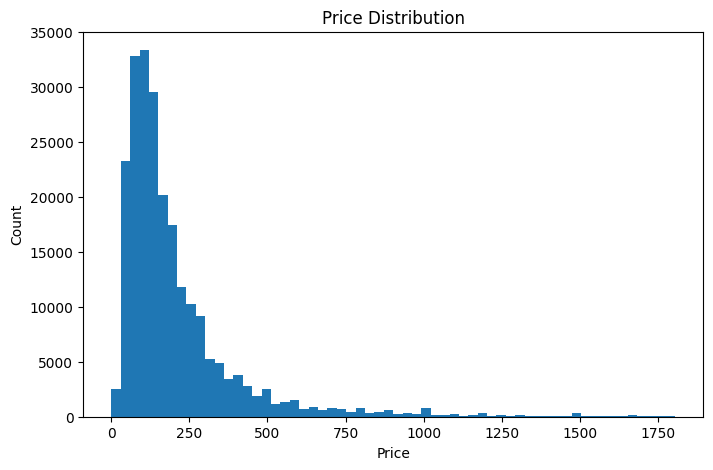

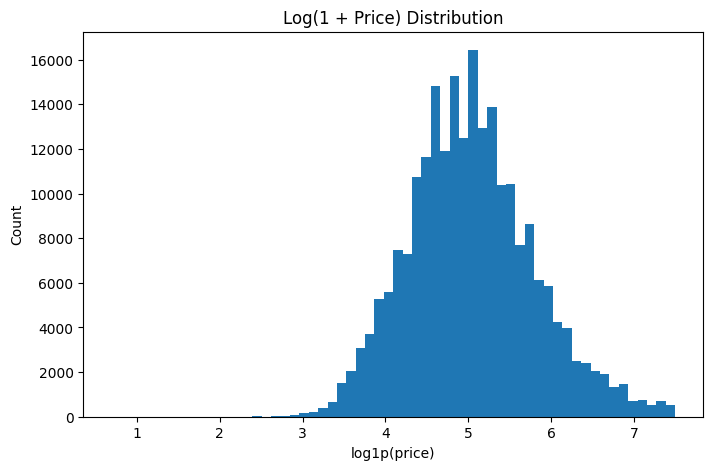

In [16]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(model_df[price_col], bins=60)
ax.set_title("Price Distribution")
ax.set_xlabel("Price")
ax.set_ylabel("Count")
plt.show()

if USE_LOG_TARGET:
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.hist(np.log1p(model_df[price_col]), bins=60)
    ax.set_title("Log(1 + Price) Distribution")
    ax.set_xlabel("log1p(price)")
    ax.set_ylabel("Count")
    plt.show()

In [17]:
numeric_cols_for_eda = model_df.select_dtypes(include=[np.number]).columns.tolist()

corr = model_df[numeric_cols_for_eda].corr(numeric_only=True)
corr[price_col].sort_values(ascending=False)

price                                   1.000000
neighbourhood_freq                      0.092939
availability_365                        0.074781
log1p_calculated_host_listings_count    0.056817
calculated_host_listings_count         -0.003230
longitude                              -0.019727
log1p_number_of_reviews_ltm            -0.051215
days_since_last_review                 -0.052324
number_of_reviews_ltm                  -0.063848
reviews_per_month                      -0.063878
number_of_reviews                      -0.085522
minimum_nights                         -0.089140
has_last_review                        -0.091504
has_reviews_per_month                  -0.091504
log1p_number_of_reviews                -0.093102
log1p_minimum_nights                   -0.134505
latitude                               -0.143273
Name: price, dtype: float64

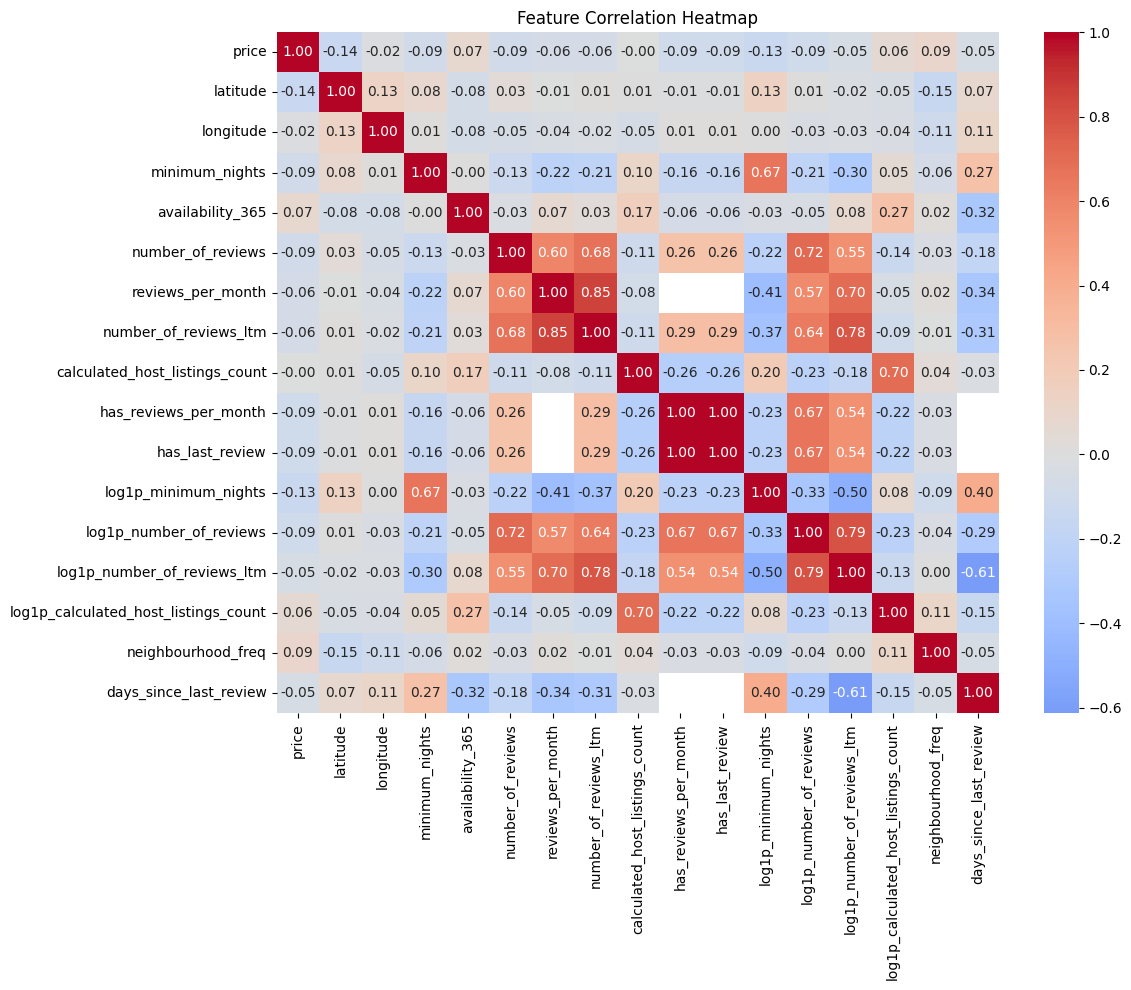

In [18]:
# Correlation heatmap
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

,count,median,mean
room_type,,,
Hotel room,757,220.0,452.632761
Entire home/apt,167438,175.0,242.823379
Private room,59286,75.0,118.636963
Shared room,2267,42.0,75.801059


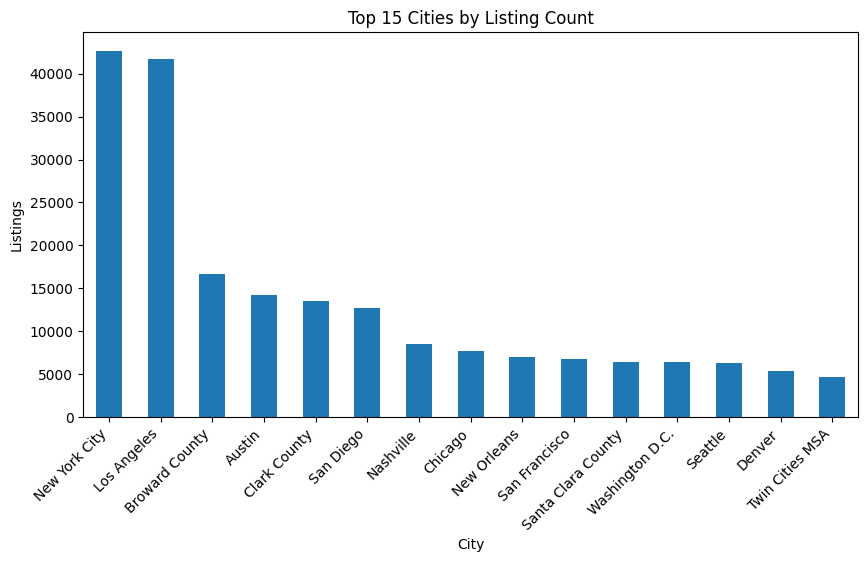

In [19]:
# Price by room type
if room_type_col is not None:
    room_price = (
        model_df.groupby(room_type_col)[price_col]
        .agg(["count", "median", "mean"])
        .sort_values("median", ascending=False)
    )
    display(room_price)

# Top cities by listing count
if city_col is not None:
    top_cities = model_df[city_col].value_counts().head(15)
    fig, ax = plt.subplots(figsize=(10, 5))
    top_cities.plot(kind="bar", ax=ax)
    ax.set_title("Top 15 Cities by Listing Count")
    ax.set_xlabel("City")
    ax.set_ylabel("Listings")
    plt.xticks(rotation=45, ha="right")
    plt.show()

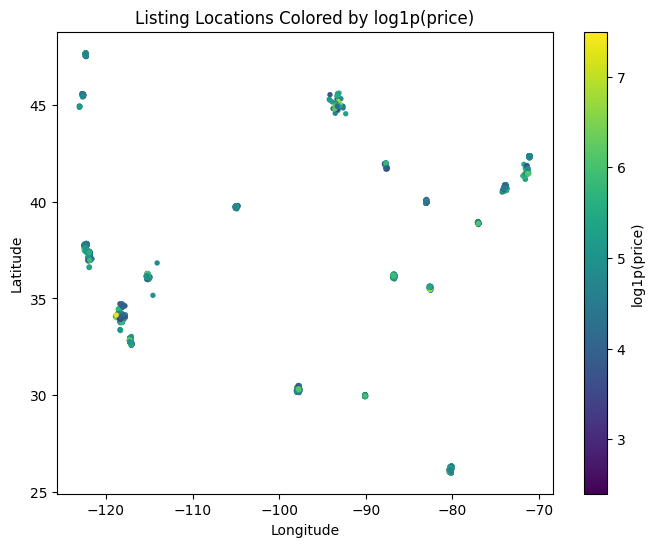

In [20]:
# Scatter plot for geographic coordinates if available
if lat_col is not None and lon_col is not None:
    sample = model_df.sample(min(len(model_df), 5000), random_state=RANDOM_STATE)
    fig, ax = plt.subplots(figsize=(8, 6))
    sc = ax.scatter(sample[lon_col], sample[lat_col], c=np.log1p(sample[price_col]), s=8)
    ax.set_title("Listing Locations Colored by log1p(price)")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    plt.colorbar(sc, ax=ax, label="log1p(price)")
    plt.show()

## 9. Train/test split

We hold out a final test set and do model selection with cross-validation on the training set.

In [21]:
X = model_df.drop(columns=[price_col]).copy()
y_raw = model_df[price_col].copy()
y = np.log1p(y_raw) if USE_LOG_TARGET else y_raw.copy()

X_train, X_test, y_train, y_test, y_raw_train, y_raw_test = train_test_split(
    X, y, y_raw, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (183798, 19)
Test shape: (45950, 19)


## 10. Baselines

The report describes two non-ML baselines:
1. **global mean predictor**
2. **simple geographic segmentation**, which we implement as a **city mean predictor** when city is available fileciteturn0file2L98-L118

In [22]:
def regression_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
    }

baseline_results = []

# Baseline 1: global mean on raw prices
global_mean = y_raw_train.mean()
pred_global = np.full(shape=len(y_raw_test), fill_value=global_mean)
baseline_results.append({
    "model": "Global Mean Baseline",
    **regression_metrics(y_raw_test, pred_global)
})

# Baseline 2: city mean
if city_col is not None and city_col in X_train.columns:
    city_means = pd.DataFrame({city_col: X_train[city_col], "price": y_raw_train}).groupby(city_col)["price"].mean()
    fallback = y_raw_train.mean()
    pred_city = X_test[city_col].map(city_means).fillna(fallback).to_numpy()
    baseline_results.append({
        "model": "City Mean Baseline",
        **regression_metrics(y_raw_test, pred_city)
    })

baseline_results_df = pd.DataFrame(baseline_results).sort_values("MAE")
baseline_results_df

,model,MAE,RMSE,R2
1,City Mean Baseline,127.841633,205.479510,4.061006e-02
0,Global Mean Baseline,132.457871,209.783359,-4.425532e-07


## 11. Preprocessing pipeline

In [23]:
numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = [c for c in X_train.columns if c not in numeric_features]

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)
print(f"\nTotal feature count: {len(numeric_features)} numeric + {len(categorical_features)} categorical")

# --- Build preprocessing pipelines ---
# StandardScaler: zero-mean, unit-variance — best for Ridge/Lasso/Linear (assumes Gaussian-like)
# This is critical for regularized models where coefficient magnitudes matter.

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

Numeric features: ['latitude', 'longitude', 'minimum_nights', 'availability_365', 'number_of_reviews', 'reviews_per_month', 'number_of_reviews_ltm', 'calculated_host_listings_count', 'has_reviews_per_month', 'has_last_review', 'log1p_minimum_nights', 'log1p_number_of_reviews', 'log1p_number_of_reviews_ltm', 'log1p_calculated_host_listings_count', 'neighbourhood_freq', 'days_since_last_review']
Categorical features: ['city', 'neighbourhood_group', 'room_type']

Total feature count: 16 numeric + 3 categorical


## 11a. Impact of Feature Scaling

The professor flagged that we should **standardize and normalize** our data. Here we compare three approaches:

| Method | Formula | When to use |
|--------|---------|-------------|
| **No scaling** | Raw values | Tree-based models (scale-invariant) |
| **StandardScaler** | `(x - mean) / std` → zero-mean, unit-variance | Linear/Ridge/Lasso — penalization is sensitive to feature magnitudes |
| **MinMaxScaler** | `(x - min) / (max - min)` → [0, 1] range | When features need bounded range; neural networks |

**Why scaling matters for this dataset:** Our numeric features span very different ranges — latitude (~30–45), minimum_nights (1–1250), number_of_reviews (0–2084). Without scaling, Ridge/Lasso penalize large-magnitude features disproportionately, and linear models' coefficients become uninterpretable.

Scaling comparison on Ridge regression:


,Scaler,CV MAE,CV R2
0,No Scaling,0.468390,0.355269
1,StandardScaler,0.466309,0.360680
2,MinMaxScaler,0.466411,0.360322


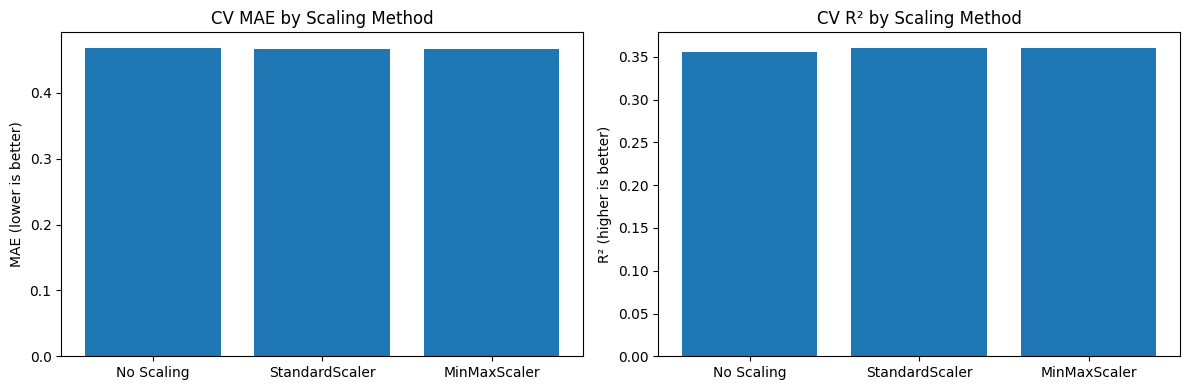

In [24]:
# Compare scaling strategies on Ridge regression (most sensitive to scaling)
scaling_comparison = []

scalers = {
    "No Scaling": None,
    "StandardScaler": StandardScaler(),
    "MinMaxScaler": MinMaxScaler(),
}

cv_scaling = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

for scaler_name, scaler_obj in scalers.items():
    if scaler_obj is not None:
        num_pipe = Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", scaler_obj)])
    else:
        num_pipe = Pipeline([("imputer", SimpleImputer(strategy="median"))])

    pre = ColumnTransformer(transformers=[
        ("num", num_pipe, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ])

    pipe = Pipeline([("preprocessor", pre), ("model", Ridge(alpha=1.0))])

    scores = cross_validate(
        pipe, X_train, y_train, cv=cv_scaling,
        scoring={"mae": "neg_mean_absolute_error", "r2": "r2"},
        n_jobs=-1,
    )
    scaling_comparison.append({
        "Scaler": scaler_name,
        "CV MAE": -scores["test_mae"].mean(),
        "CV R2": scores["test_r2"].mean(),
    })

scaling_df = pd.DataFrame(scaling_comparison)
print("Scaling comparison on Ridge regression:")
display(scaling_df)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(scaling_df["Scaler"], scaling_df["CV MAE"])
axes[0].set_title("CV MAE by Scaling Method")
axes[0].set_ylabel("MAE (lower is better)")
axes[1].bar(scaling_df["Scaler"], scaling_df["CV R2"])
axes[1].set_title("CV R² by Scaling Method")
axes[1].set_ylabel("R² (higher is better)")
plt.tight_layout()
plt.show()

## 12. Candidate models

This matches the planned comparison from the report:
- Linear Regression
- Ridge
- Lasso
- Random Forest Regressor
- Gradient Boosting Regressor fileciteturn0file2L86-L106

In [25]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.001),

    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        max_depth=20,
        min_samples_leaf=5,
        max_features="sqrt",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.1,
        max_depth=5,
        subsample=0.8,
        random_state=RANDOM_STATE,
    ),
}

cv = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
cv_rows = []

for name, model in models.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model),
    ])

    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring={
            "mae": "neg_mean_absolute_error",
            "rmse": "neg_root_mean_squared_error",
            "r2": "r2",
        },
        n_jobs=-1,
        return_train_score=False,
    )

    cv_rows.append({
        "model": name,
        "cv_MAE": -scores["test_mae"].mean(),
        "cv_RMSE": -scores["test_rmse"].mean(),
        "cv_R2": scores["test_r2"].mean(),
    })
    print(f"  {name}: MAE={-scores['test_mae'].mean():.4f}, R2={scores['test_r2'].mean():.4f}")

cv_results = pd.DataFrame(cv_rows).sort_values("cv_MAE")
cv_results

  Linear Regression: MAE=0.4652, R2=0.3636
  Ridge: MAE=0.4663, R2=0.3607
  Lasso: MAE=0.4698, R2=0.3533
  Random Forest: MAE=0.3912, R2=0.5328
  Gradient Boosting: MAE=0.3909, R2=0.5368


,model,cv_MAE,cv_RMSE,cv_R2
4,Gradient Boosting,0.390902,0.517042,0.536838
3,Random Forest,0.391150,0.519287,0.532807
0,Linear Regression,0.465201,0.606088,0.363568
1,Ridge,0.466309,0.607461,0.360680
2,Lasso,0.469829,0.610961,0.353292


## 12a. Hyperparameter Tuning (Gradient Boosting)

We use RandomizedSearchCV on the best-performing model to find better hyperparameters. This searches over learning rate, depth, number of estimators, and subsampling rate.

In [26]:
gb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor(random_state=RANDOM_STATE)),
])

param_dist = {
    "model__n_estimators": [200, 300, 500],
    "model__learning_rate": [0.05, 0.1, 0.15],
    "model__max_depth": [4, 5, 6, 8],
    "model__subsample": [0.7, 0.8, 0.9],
    "model__min_samples_leaf": [5, 10, 20],
}

search = RandomizedSearchCV(
    gb_pipeline,
    param_distributions=param_dist,
    n_iter=20,
    scoring="neg_mean_absolute_error",
    cv=KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE),
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
)

search.fit(X_train, y_train)

print(f"\nBest CV MAE: {-search.best_score_:.4f}")
print("Best params:")
for k, v in search.best_params_.items():
    print(f"  {k}: {v}")

# Add tuned model to our collection
models["Gradient Boosting (Tuned)"] = search.best_estimator_.named_steps["model"]

Fitting 3 folds for each of 20 candidates, totalling 60 fits

Best CV MAE: 0.3656
Best params:
  model__subsample: 0.8
  model__n_estimators: 500
  model__min_samples_leaf: 5
  model__max_depth: 8
  model__learning_rate: 0.1


## 13. Final training and test evaluation

When `USE_LOG_TARGET = True`, models are fit on `log1p(price)` and predictions are transformed back with `expm1(...)` before final MAE and RMSE are reported on the original price scale.

In [27]:
fitted_pipelines = {}
test_rows = []

for name, model in models.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model),
    ])
    pipeline.fit(X_train, y_train)
    fitted_pipelines[name] = pipeline

    pred_test_model_scale = pipeline.predict(X_test)
    if USE_LOG_TARGET:
        pred_test_raw = np.expm1(pred_test_model_scale)
    else:
        pred_test_raw = pred_test_model_scale

    pred_test_raw = np.clip(pred_test_raw, a_min=0, a_max=None)

    test_rows.append({
        "model": name,
        **regression_metrics(y_raw_test, pred_test_raw),
    })

test_results = pd.DataFrame(test_rows).sort_values("MAE")
test_results

,model,MAE,RMSE,R2
5,Gradient Boosting (Tuned),82.150442,161.873623,0.404598
4,Gradient Boosting,87.643905,171.748716,0.329737
3,Random Forest,87.699087,174.406967,0.308829
0,Linear Regression,101.860186,195.885529,0.128108
1,Ridge,102.051803,196.340805,0.124050
2,Lasso,102.540937,197.493997,0.113730


In [28]:
all_results = pd.concat(
    [baseline_results_df, test_results],
    ignore_index=True
).sort_values("MAE")

all_results

,model,MAE,RMSE,R2
2,Gradient Boosting (Tuned),82.150442,161.873623,4.045980e-01
3,Gradient Boosting,87.643905,171.748716,3.297372e-01
4,Random Forest,87.699087,174.406967,3.088286e-01
5,Linear Regression,101.860186,195.885529,1.281077e-01
6,Ridge,102.051803,196.340805,1.240501e-01
7,Lasso,102.540937,197.493997,1.137303e-01
0,City Mean Baseline,127.841633,205.479510,4.061006e-02
1,Global Mean Baseline,132.457871,209.783359,-4.425532e-07


## 14. Best model inspection

In [29]:
best_model_name = test_results.sort_values("MAE").iloc[0]["model"]
best_pipeline = fitted_pipelines[best_model_name]
best_estimator = best_pipeline.named_steps["model"]

print("Best model:", best_model_name)
print(f"Test MAE: {test_results.sort_values('MAE').iloc[0]['MAE']:.2f}")
print(f"Test R²:  {test_results.sort_values('MAE').iloc[0]['R2']:.4f}")

Best model: Gradient Boosting (Tuned)
Test MAE: 82.15
Test R²:  0.4046


## Model Comparison Bar Chart

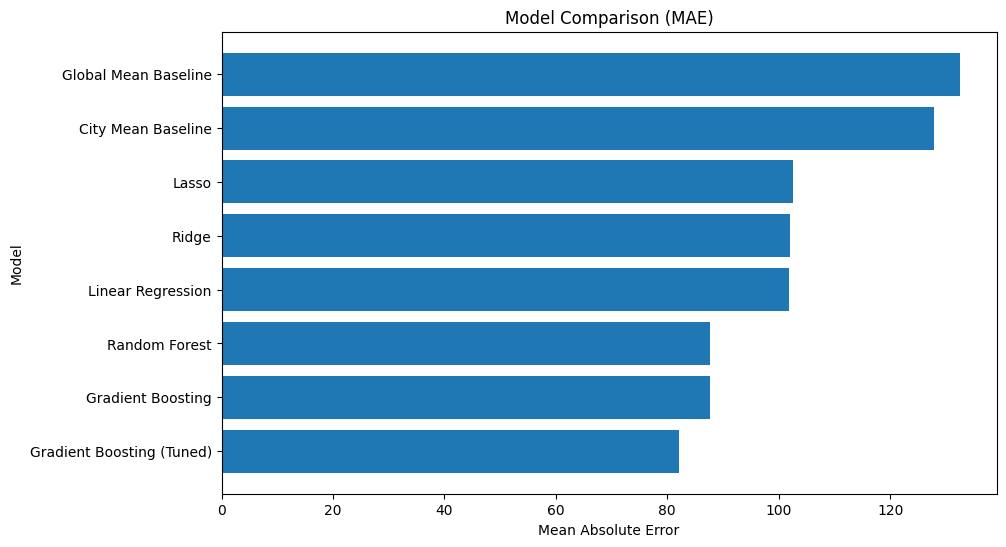

In [30]:
fig, ax = plt.subplots(figsize=(10, 6))

all_results_sorted = all_results.sort_values("MAE")

ax.barh(all_results_sorted["model"], all_results_sorted["MAE"])
ax.set_title("Model Comparison (MAE)")
ax.set_xlabel("Mean Absolute Error")
ax.set_ylabel("Model")

plt.show()

## RMSE + R² Comparison

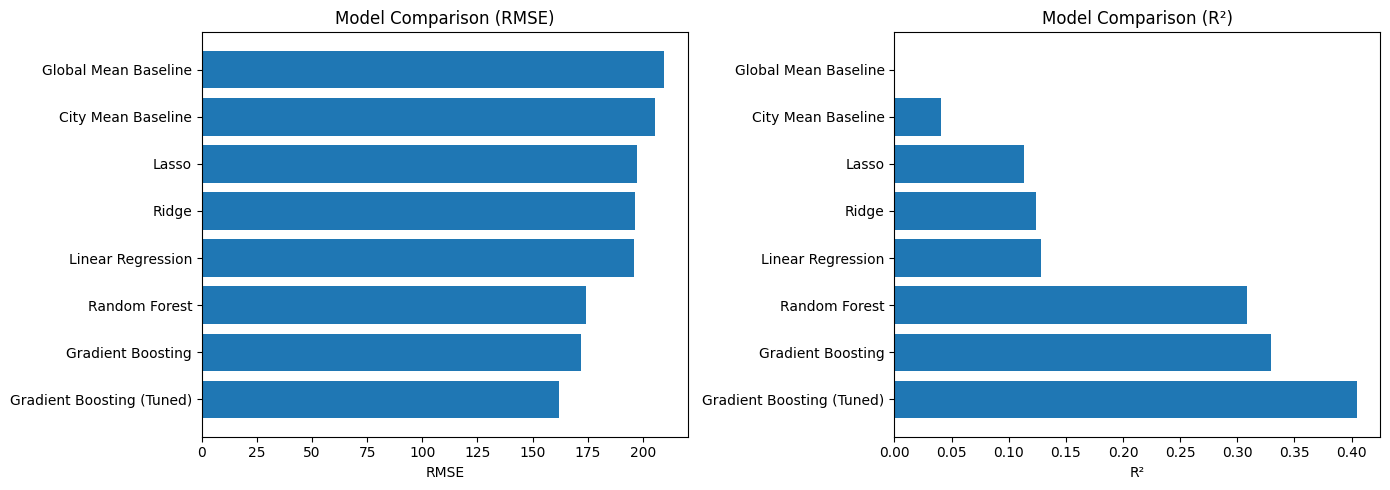

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# RMSE
axes[0].barh(all_results_sorted["model"], all_results_sorted["RMSE"])
axes[0].set_title("Model Comparison (RMSE)")
axes[0].set_xlabel("RMSE")

# R2
axes[1].barh(all_results_sorted["model"], all_results_sorted["R2"])
axes[1].set_title("Model Comparison (R²)")
axes[1].set_xlabel("R²")

plt.tight_layout()
plt.show()

## Predicted vs Actual Plot

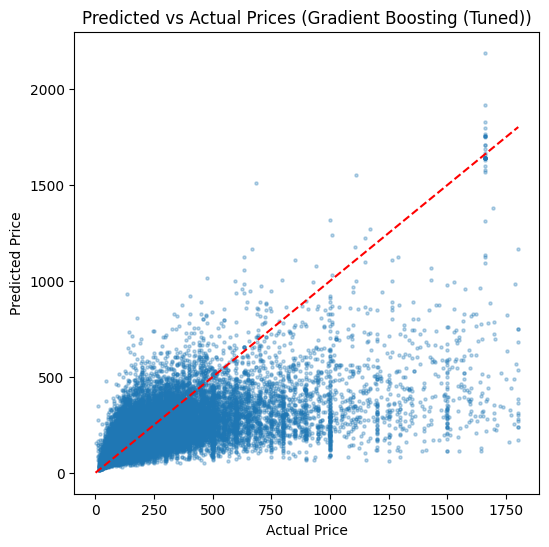

In [32]:
# Generate predictions from best model
preds = best_pipeline.predict(X_test)
if USE_LOG_TARGET:
    preds = np.expm1(preds)
preds = np.clip(preds, a_min=0, a_max=None)

# Compute residuals
residuals = y_raw_test.values - preds

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_raw_test, preds, alpha=0.3, s=5)
ax.plot([y_raw_test.min(), y_raw_test.max()],
        [y_raw_test.min(), y_raw_test.max()],
        'r--')

ax.set_xlabel("Actual Price")
ax.set_ylabel("Predicted Price")
ax.set_title(f"Predicted vs Actual Prices ({best_model_name})")

plt.show()

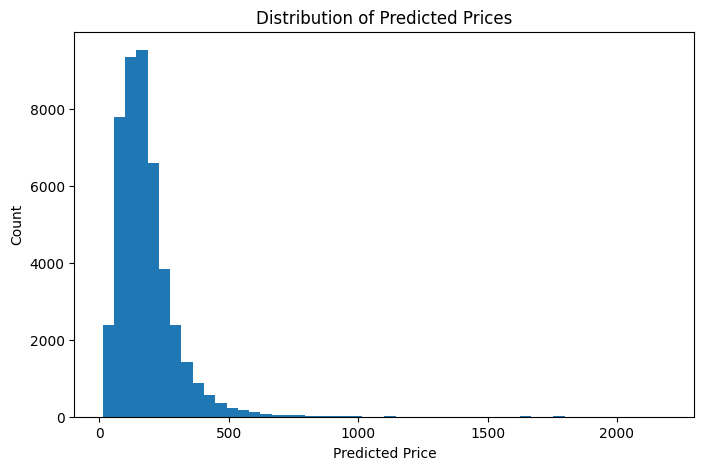

In [33]:
plt.figure(figsize=(8,5))
plt.hist(preds, bins=50)

plt.title("Distribution of Predicted Prices")
plt.xlabel("Predicted Price")
plt.ylabel("Count")
plt.show()

## Residual Plot

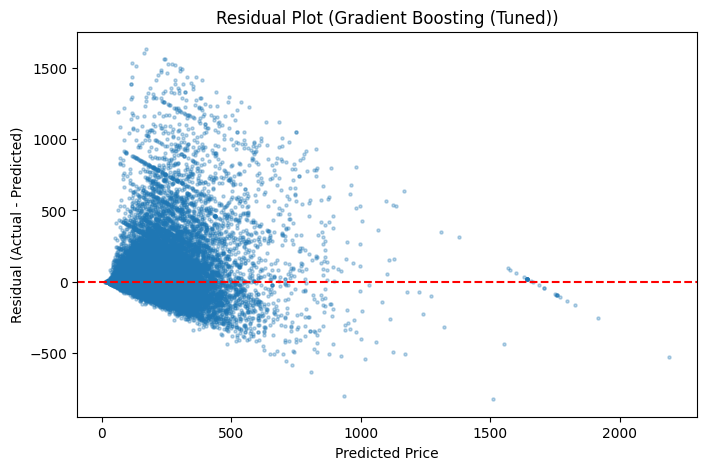

In [34]:
# residuals already computed above
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(preds, residuals, alpha=0.3, s=5)
ax.axhline(0, color='red', linestyle='--')

ax.set_xlabel("Predicted Price")
ax.set_ylabel("Residual (Actual - Predicted)")
ax.set_title(f"Residual Plot ({best_model_name})")

plt.show()

## Error Analysis by Segment

Breaking down prediction errors by room type and price tier reveals where the model struggles most.

In [35]:
# Error analysis by room type
error_df = X_test.copy()
error_df["actual"] = y_raw_test.values
error_df["predicted"] = preds
error_df["abs_error"] = np.abs(residuals)

if room_type_col and room_type_col in error_df.columns:
    error_by_room = error_df.groupby(room_type_col).agg(
        count=("abs_error", "size"),
        median_price=("actual", "median"),
        mean_abs_error=("abs_error", "mean"),
        median_abs_error=("abs_error", "median"),
    ).sort_values("mean_abs_error", ascending=False)
    print("Error breakdown by room type:")
    display(error_by_room)

# Error by price tier
error_df["price_tier"] = pd.cut(
    error_df["actual"],
    bins=[0, 75, 150, 300, 600, 2000],
    labels=["$0-75", "$75-150", "$150-300", "$300-600", "$600+"]
)
error_by_tier = error_df.groupby("price_tier", observed=True).agg(
    count=("abs_error", "size"),
    mean_abs_error=("abs_error", "mean"),
    median_abs_error=("abs_error", "median"),
    mean_pct_error=("abs_error", lambda x: (x / error_df.loc[x.index, "actual"] * 100).mean()),
).round(2)
print("\nError breakdown by price tier:")
display(error_by_tier)

Error breakdown by room type:


,count,median_price,mean_abs_error,median_abs_error
room_type,,,,
Entire home/apt,33550,175.0,96.862054,51.838176
Hotel room,173,248.0,77.671188,44.635139
Private room,11774,75.0,41.938451,16.990521
Shared room,453,42.0,39.449189,10.650463



Error breakdown by price tier:


,count,mean_abs_error,median_abs_error,mean_pct_error
price_tier,,,,
$0-75,8051,26.74,15.75,54.03
$75-150,16134,42.34,29.92,38.83
$150-300,13755,56.78,44.77,26.55
$300-600,5831,153.43,141.33,36.14
$600+,2179,551.03,501.48,57.13


## Price Distribution by Room Type

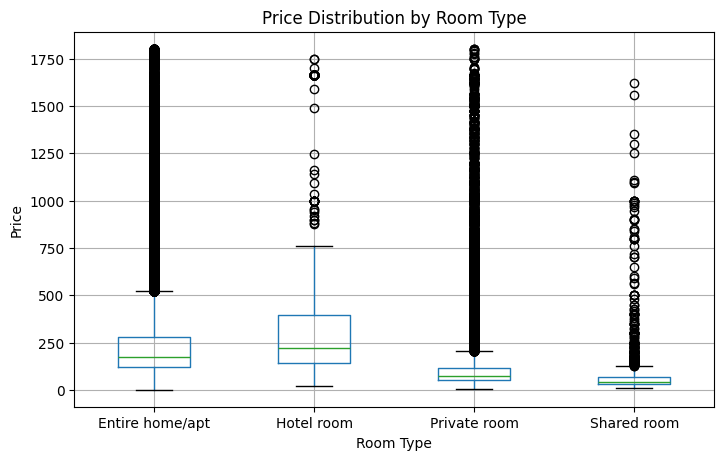

In [36]:
if room_type_col is not None:
    fig, ax = plt.subplots(figsize=(8, 5))

    model_df.boxplot(column=price_col, by=room_type_col, ax=ax)

    ax.set_title("Price Distribution by Room Type")
    ax.set_xlabel("Room Type")
    ax.set_ylabel("Price")
    plt.suptitle("")

    plt.show()

## Top 10 Feature Importances

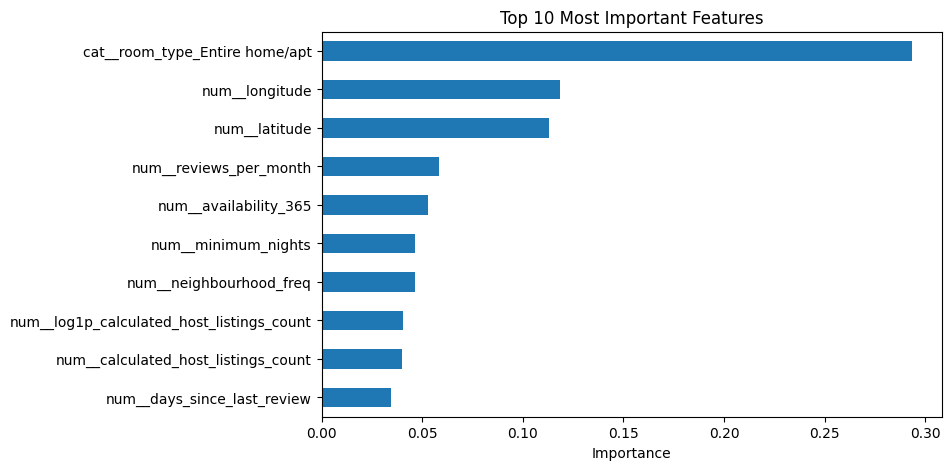

In [37]:
if hasattr(best_estimator, "feature_importances_"):
    feature_names = best_pipeline.named_steps["preprocessor"].get_feature_names_out()
    importances = pd.Series(best_estimator.feature_importances_, index=feature_names)

    top_features = importances.sort_values(ascending=False).head(10)

    fig, ax = plt.subplots(figsize=(8, 5))
    top_features[::-1].plot(kind="barh", ax=ax)

    ax.set_title("Top 10 Most Important Features")
    ax.set_xlabel("Importance")

    plt.show()

## 15. Key Findings

**Data Quality**
- Raw dataset contains 232,147 listings across 27 U.S. cities with 18 columns
- After cleaning invalid prices and removing the top 1% of price outliers, the final modeling dataset contains 229,748 listings
- Price is heavily right-skewed, with mean price around $210 and median price $148
- Top 1% outlier removal (>$1,803/night) eliminates extreme values that distort model training
- `neighbourhood_group` has substantial missingness, and `reviews_per_month` is missing for about 21% of rows, likely because many listings have no reviews

**Feature Engineering**
- `neighbourhood` was frequency-encoded instead of one-hot encoded to avoid a massive sparse feature matrix
- Log-transformed skewed features (`minimum_nights`, `number_of_reviews`, `number_of_reviews_ltm`, `calculated_host_listings_count`) to reduce outlier influence
- Added `days_since_last_review` as a proxy for listing activity and review recency
- Added missingness indicators such as `has_reviews_per_month` and `has_last_review` so the model can capture whether a listing has review history

**Scaling & Normalization**
- StandardScaler was applied to numeric features for the main modeling pipeline
- Scaling is especially important for Ridge and Lasso because regularization depends on coefficient magnitudes
- The scaling comparison showed that StandardScaler and MinMaxScaler improve regularized linear model performance compared with no scaling
- Tree-based models such as Random Forest and Gradient Boosting are mostly scale-invariant, but using a consistent preprocessing pipeline keeps the workflow cleaner and reproducible

**Model Performance**
- Tuned Gradient Boosting was the best final model: MAE = 82.15, RMSE = 161.87, R² = 0.405
- Untuned Gradient Boosting and Random Forest performed similarly: Gradient Boosting had MAE = 87.64 and Random Forest had MAE = 87.70
- Linear Regression performed worse than the tree-based models, with MAE = 101.86 and R² = 0.128
- All machine learning models beat both baselines: Global Mean baseline MAE = 132.46 and City Mean baseline MAE = 127.84
- Room type and geography are the strongest pricing signals, while review and host features add useful but limited signal

**Limitations**
- R² remains moderate, meaning the available features explain only part of Airbnb pricing
- The model still struggles with expensive listings, where errors are larger and predictions tend to be too low
- The dataset lacks important interior and quality features such as bedrooms, bathrooms, amenities, photos, cleaning fees, review scores, and seasonal demand
- Static 2023 snapshot data does not capture dynamic pricing, local events, or seasonality
- The model should be treated as a baseline pricing estimator for typical U.S. listings, not a full dynamic pricing system

## 16. Next Steps

1. **Incorporate richer features** — scrape or join amenities, bedroom/bathroom counts, and description text (TF-IDF) from detailed Airbnb data
2. **Target encoding for neighbourhood** — use cross-validated target encoding instead of frequency encoding for stronger signal
3. **XGBoost / LightGBM** — typically outperform sklearn's GradientBoostingRegressor with faster training
4. **Per-city models** — train separate models per city to capture local market dynamics
5. **Temporal analysis** — compare 2020 vs 2023 data to study post-pandemic price shifts
6. **SHAP values** — go beyond feature importance to show directional effects (e.g., does Private room increase or decrease price?)